# Preliminari

In [135]:
import sys
from pathlib import Path

# if notebook is in PRIN/notebooks, parent() is PRIN
project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))
print("Added to sys.path:", project_root)

import os
from openai import OpenAI
from dotenv import load_dotenv  
from pprint import pprint
import time
import json

from pydantic import BaseModel
from textwrap import dedent
from IPython.display import Math

from pathlib import Path

from utils.schema_json import ReportData

from pydantic import BaseModel
from time import perf_counter
from openai.types.fine_tuning import SupervisedMethod, SupervisedHyperparameters

from utils.schema_json import ReportData, AnnotatedReport
import pandas as pd
import seaborn as sns
import numpy as np

Added to sys.path: C:\Users\lucat\PythonRepositories\PRIN


In [87]:
load_dotenv()  # Load environment variables from .env file

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

# Parametri

In [88]:
TRAIN_FILE_NAME = "data_finetune_guido_openai_train.jsonl"
VALIDATION_FILE_NAME = "data_finetune_guido_openai_val.jsonl"
#MODEL = "gpt-4.1-2025-04-14"
MODEL = "gpt-4.1-nano-2025-04-14" # Nano
SEED = 2025
TIPO = 'openai'

# **Oversampling**
We use oversampling to duplicate rare records.

We will need a rarity measure. Oversampling applied only on train dataset.

In [89]:
# Carichiamo i nostri file JSON
file_names = {
    'train': TRAIN_FILE_NAME
}

paths = {
    split: Path('../data/ft-dataset/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    with open(path, "r", encoding="utf-8") as f:
        data_list = [json.loads(line) for line in f]
        data[split] = data_list

train_data = data['train']

print(f"{len(train_data) = }")
print(f"{type(train_data[0]) = }")
print(f"{type(train_data[0]['messages'][1]['content']) = }")  # Report text
print(f"{type(train_data[0]['messages'][2]['content']) = }")  # Annotations

len(train_data) = 116
type(train_data[0]) = <class 'dict'>
type(train_data[0]['messages'][1]['content']) = <class 'str'>
type(train_data[0]['messages'][2]['content']) = <class 'str'>


In [90]:
annotated_reports: dict[str, list[AnnotatedReport]] = {split: [] for split in file_names.keys()}
for split in annotated_reports:
    for record in data[split]:
        report_text = record['messages'][1]['content'].lower()  # Tutte lettere minuscole
        if TIPO == 'openai':
            report_data = ReportData.model_validate_json(record['messages'][2]['content'])
        else:
            report_data = ReportData.model_validate(record['messages'][2]['content'])
        annotated_reports[split].append(AnnotatedReport(report_text=report_text, report_data=report_data))

In [91]:
train_data = annotated_reports['train']

In [92]:
def report_data_to_one_level(annotated_report: AnnotatedReport) -> dict:
    result = {
        'report_text': annotated_report.report_text
    }
    for k, v in annotated_report.report_data.model_dump().items():
        if isinstance(v, dict):
            for kk, vv in v.items():
                key_string = k + '_' + kk
                result[key_string] = vv
        else:
            result[k] = v
    return result

In [93]:
train_data_one_level = [report_data_to_one_level(r) for r in train_data]

In [94]:
# Create dataset to compute rarity
df = pd.DataFrame.from_records(train_data_one_level)

In [95]:
# Swap null with string 'NaN'
df = df.fillna('NaN')
display(df.head(2))

,report_text,morfologia,posizione_basso,posizione_medio,posizione_alto,posizione_giunzione,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,...,sedi_linfonodi_altro,depositi_tumorali,numero_depositi,emvi_esteso,stadio_T,stadio_N,stadio_N1c,mrf,emvi,metastasi
0,si segnala la presenza in corrispondenza del r...,solido_anulare,True,False,False,False,12.0,12.0,NaN,60.0,...,False,NaN,0,no,T4b,N+,False,NaN,NaN,NaN
1,"in corrispondenza del retto medio- basso , da ...",solido_polipoide,True,True,False,False,NaN,NaN,NaN,48.0,...,False,NaN,0,si,T4b,N2a,False,NaN,+,NaN


In [ ]:
numerical_columns = [
    'ore_inizio',
    'ore_fine',
    'spessore_parietale',
    'estensione_cranio_caudale',
    'distanza_oai',
    'linfonodi_sospetti',
    'numero_depositi'
]
for j, col in enumerate(df.columns):
    if col not in numerical_columns + ['report_text']:
        val_count = df[col].value_counts()
        # Swap value with its count
        for i in range(df.shape[0]):
            df.iloc[i, j] = val_count[df.iloc[i, j]]
    elif col == 'linfonodi_sospetti':
        val_count = df[col].value_counts()
        # Swap value with its count
        for i in range(df.shape[0]):
            df.iloc[i, j] = val_count[df.iloc[i, j]]
    elif col == 'numero_depositi':
        # Swap NaN with 0
        for i in range(df.shape[0]):
            if df.iloc[i, j] == 'NaN':
                df.iloc[i, j] = 0.0        
        val_count = df[col].value_counts()
        # Swap value with its count
        for i in range(df.shape[0]):
            df.iloc[i, j] = val_count[df.iloc[i, j]]
    elif col in ['ore_inizio', 'ore_fine']:
        val_count = df[col].value_counts()
        # Swap value with its count
        for i in range(df.shape[0]):
            df.iloc[i, j] = val_count[df.iloc[i, j]]
    elif col in ['estensione_cranio_caudale', 'distanza_oai', 'spessore_parietale']:
        for i in range(df.shape[0]):
            if isinstance(df.iloc[i, j], str):
                df.iloc[i, j] = df.shape[0]
            else:
                if df.iloc[i, j] == 0:
                    df.iloc[i, j] = df.shape[0]
                else: df.iloc[i, j] = df.shape[0] // 2
                
df[df.columns[1:]] = df[df.columns[1:]].astype(float)

C:\Users\lucat\AppData\Local\Temp\ipykernel_14728\4201459931.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '43' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.iloc[i, j] = val_count[df.iloc[i, j]]
C:\Users\lucat\AppData\Local\Temp\ipykernel_14728\4201459931.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '51' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.iloc[i, j] = val_count[df.iloc[i, j]]
C:\Users\lucat\AppData\Local\Temp\ipykernel_14728\4201459931.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '69' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.iloc[i, j] = val_count[df.iloc[i, j]]
C:\Users\l

In [104]:
df[df.columns[1:]].head()

,morfologia,posizione_basso,posizione_medio,posizione_alto,posizione_giunzione,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,...,sedi_linfonodi_altro,depositi_tumorali,numero_depositi,emvi_esteso,stadio_T,stadio_N,stadio_N1c,mrf,emvi,metastasi
0,64.0,43.0,51.0,69.0,111.0,26.0,33.0,116.0,58.0,116.0,...,108.0,48.0,111.0,98.0,30.0,24.0,109.0,71.0,93.0,110.0
1,41.0,43.0,65.0,69.0,111.0,69.0,69.0,116.0,58.0,58.0,...,108.0,48.0,111.0,18.0,30.0,29.0,109.0,71.0,17.0,110.0
2,64.0,73.0,65.0,47.0,111.0,69.0,69.0,116.0,58.0,58.0,...,108.0,48.0,111.0,98.0,32.0,30.0,109.0,71.0,93.0,110.0
3,41.0,43.0,51.0,69.0,111.0,69.0,69.0,116.0,116.0,116.0,...,108.0,48.0,111.0,98.0,30.0,29.0,109.0,37.0,93.0,110.0
4,64.0,73.0,65.0,47.0,111.0,10.0,2.0,116.0,58.0,58.0,...,108.0,48.0,111.0,98.0,13.0,30.0,109.0,71.0,93.0,110.0


In [105]:
df_frequency = df[df.columns[1:]] / df.shape[0]

In [106]:
df_frequency

,morfologia,posizione_basso,posizione_medio,posizione_alto,posizione_giunzione,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,...,sedi_linfonodi_altro,depositi_tumorali,numero_depositi,emvi_esteso,stadio_T,stadio_N,stadio_N1c,mrf,emvi,metastasi
0,0.551724,0.37069,0.439655,0.594828,0.956897,0.224138,0.284483,1.0,0.5,1.0,...,0.931034,0.413793,0.956897,0.844828,0.258621,0.206897,0.939655,0.612069,0.801724,0.948276
1,0.353448,0.37069,0.560345,0.594828,0.956897,0.594828,0.594828,1.0,0.5,0.5,...,0.931034,0.413793,0.956897,0.155172,0.258621,0.250000,0.939655,0.612069,0.146552,0.948276
2,0.551724,0.62931,0.560345,0.405172,0.956897,0.594828,0.594828,1.0,0.5,0.5,...,0.931034,0.413793,0.956897,0.844828,0.275862,0.258621,0.939655,0.612069,0.801724,0.948276
3,0.353448,0.37069,0.439655,0.594828,0.956897,0.594828,0.594828,1.0,1.0,1.0,...,0.931034,0.413793,0.956897,0.844828,0.258621,0.250000,0.939655,0.318966,0.801724,0.948276
4,0.551724,0.62931,0.560345,0.405172,0.956897,0.086207,0.017241,1.0,0.5,0.5,...,0.931034,0.413793,0.956897,0.844828,0.112069,0.258621,0.939655,0.612069,0.801724,0.948276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,0.551724,0.37069,0.560345,0.405172,0.956897,0.224138,0.284483,0.5,0.5,0.5,...,0.931034,0.525862,0.956897,0.844828,0.258621,0.206897,0.939655,0.318966,0.801724,0.948276
112,0.551724,0.62931,0.560345,0.594828,0.956897,0.086207,0.284483,1.0,0.5,0.5,...,0.931034,0.525862,0.956897,0.844828,0.025862,0.060345,0.939655,0.068966,0.801724,0.008621
113,0.551724,0.62931,0.560345,0.405172,0.956897,0.224138,0.284483,1.0,0.5,0.5,...,0.931034,0.060345,0.034483,0.155172,0.112069,0.250000,0.060345,0.318966,0.146552,0.948276
114,0.353448,0.62931,0.560345,0.594828,0.956897,0.594828,0.594828,1.0,0.5,1.0,...,0.931034,0.525862,0.956897,0.844828,0.060345,0.258621,0.939655,0.068966,0.801724,0.948276


In [109]:
df_frequency['rarity'] = df_frequency.prod(axis=1)

In [110]:
df_frequency

,morfologia,posizione_basso,posizione_medio,posizione_alto,posizione_giunzione,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,...,depositi_tumorali,numero_depositi,emvi_esteso,stadio_T,stadio_N,stadio_N1c,mrf,emvi,metastasi,rarity
0,0.551724,0.37069,0.439655,0.594828,0.956897,0.224138,0.284483,1.0,0.5,1.0,...,0.413793,0.956897,0.844828,0.258621,0.206897,0.939655,0.612069,0.801724,0.948276,6.380117e-10
1,0.353448,0.37069,0.560345,0.594828,0.956897,0.594828,0.594828,1.0,0.5,0.5,...,0.413793,0.956897,0.155172,0.258621,0.250000,0.939655,0.612069,0.146552,0.948276,1.691526e-11
2,0.551724,0.62931,0.560345,0.405172,0.956897,0.594828,0.594828,1.0,0.5,0.5,...,0.413793,0.956897,0.844828,0.275862,0.258621,0.939655,0.612069,0.801724,0.948276,9.633983e-08
3,0.353448,0.37069,0.439655,0.594828,0.956897,0.594828,0.594828,1.0,1.0,1.0,...,0.413793,0.956897,0.844828,0.258621,0.250000,0.939655,0.318966,0.801724,0.948276,5.777755e-10
4,0.551724,0.62931,0.560345,0.405172,0.956897,0.086207,0.017241,1.0,0.5,0.5,...,0.413793,0.956897,0.844828,0.112069,0.258621,0.939655,0.612069,0.801724,0.948276,3.498108e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,0.551724,0.37069,0.560345,0.405172,0.956897,0.224138,0.284483,0.5,0.5,0.5,...,0.525862,0.956897,0.844828,0.258621,0.206897,0.939655,0.318966,0.801724,0.948276,1.997423e-10
112,0.551724,0.62931,0.560345,0.594828,0.956897,0.086207,0.284483,1.0,0.5,0.5,...,0.525862,0.956897,0.844828,0.025862,0.060345,0.939655,0.068966,0.801724,0.008621,1.566672e-19
113,0.551724,0.62931,0.560345,0.405172,0.956897,0.224138,0.284483,1.0,0.5,0.5,...,0.060345,0.034483,0.155172,0.112069,0.250000,0.060345,0.318966,0.146552,0.948276,2.639305e-16
114,0.353448,0.62931,0.560345,0.594828,0.956897,0.594828,0.594828,1.0,0.5,1.0,...,0.525862,0.956897,0.844828,0.060345,0.258621,0.939655,0.068966,0.801724,0.948276,1.421906e-11


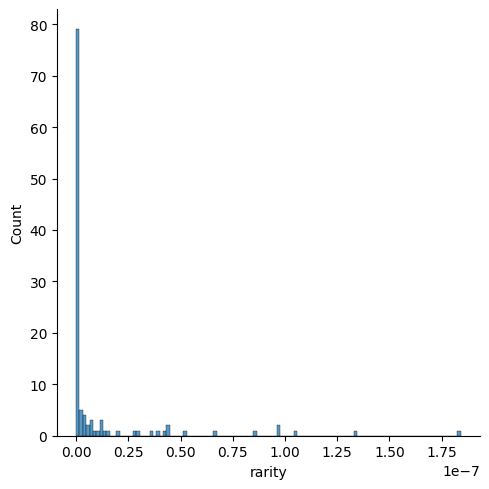

In [ ]:
sns.displot(df_frequency.rarity)

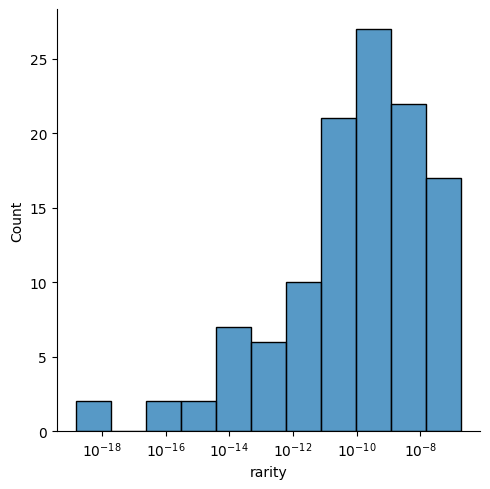

In [116]:
sns.displot(df_frequency.rarity, log_scale=(True, False))

In [129]:
# Ricarica
# Carichiamo i nostri file JSON
file_names = {
    'train': TRAIN_FILE_NAME
}

paths = {
    split: Path('../data/ft-dataset/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    with open(path, "r", encoding="utf-8") as f:
        data_list = [json.loads(line) for line in f]
        data[split] = data_list

train_data = data['train']

print(f"{len(train_data) = }")
print(f"{type(train_data[0]) = }")
print(f"{type(train_data[0]['messages'][1]['content']) = }")  # Report text
print(f"{type(train_data[0]['messages'][2]['content']) = }")  # Annotations

len(train_data) = 116
type(train_data[0]) = <class 'dict'>
type(train_data[0]['messages'][1]['content']) = <class 'str'>
type(train_data[0]['messages'][2]['content']) = <class 'str'>


In [131]:
train_df = pd.DataFrame({
    'json': train_data,
    'rarity': df_frequency.rarity
})

In [133]:
# Sort train_df
train_sorted_by_rarity = train_df.sort_values(by='rarity', ignore_index=True)

In [134]:
train_sorted_by_rarity.head()

,json,rarity
0,"{'messages': [{'role': 'system', 'content': 'S...",1.566672e-19
1,"{'messages': [{'role': 'system', 'content': 'S...",1.624524e-18
2,"{'messages': [{'role': 'system', 'content': 'S...",2.993552e-17
3,"{'messages': [{'role': 'system', 'content': 'S...",2.639305e-16
4,"{'messages': [{'role': 'system', 'content': 'S...",5.295050e-16


In [136]:
# Divide data in multiple chunks
n_chunks = 3
chunks = np.array_split(train_sorted_by_rarity, n_chunks)

c:\Users\lucat\PythonRepositories\PRIN\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [141]:
oversampling_list = []
for i, chunk in enumerate(chunks):
    oversampling_list += (n_chunks - i) * [chunk]
df_oversampled = pd.concat(oversampling_list, ignore_index=True)

In [144]:
df_oversampled.head()

,json,rarity
0,"{'messages': [{'role': 'system', 'content': 'S...",1.566672e-19
1,"{'messages': [{'role': 'system', 'content': 'S...",1.624524e-18
2,"{'messages': [{'role': 'system', 'content': 'S...",2.993552e-17
3,"{'messages': [{'role': 'system', 'content': 'S...",2.639305e-16
4,"{'messages': [{'role': 'system', 'content': 'S...",5.295050e-16


In [ ]:
# Shuffle data
df_oversampled = df_oversampled.sample(frac=1, random_state=2025).reset_index(drop=True)

,json,rarity
0,"{'messages': [{'role': 'system', 'content': 'S...",7.604429e-11
1,"{'messages': [{'role': 'system', 'content': 'S...",1.997423e-10
2,"{'messages': [{'role': 'system', 'content': 'S...",1.831816e-14
3,"{'messages': [{'role': 'system', 'content': 'S...",2.039632e-10
4,"{'messages': [{'role': 'system', 'content': 'S...",6.380117e-10
...,...,...
228,"{'messages': [{'role': 'system', 'content': 'S...",1.691526e-11
229,"{'messages': [{'role': 'system', 'content': 'S...",3.858124e-13
230,"{'messages': [{'role': 'system', 'content': 'S...",8.988954e-09
231,"{'messages': [{'role': 'system', 'content': 'S...",4.261412e-08


# Upload data
Upload a file that can be used across various endpoints. Individual files can be up to 512 MB, and the size of all files uploaded by one organization can be up to 1 TB.

The Assistants API supports files up to 2 million tokens and of specific file types. See the Assistants Tools guide for details.

The Fine-tuning API only supports .jsonl files. The input also has certain required formats for fine-tuning chat or completions models.

The Batch API only supports .jsonl files up to 200 MB in size. The input also has a specific required format.

Please contact us if you need to increase these storage limits.

In [4]:
train_path = Path('../data/ft-dataset/' + TRAIN_FILE_NAME)
print(train_path)

validation_path = Path('../data/ft-dataset/' + VALIDATION_FILE_NAME)
print(validation_path)

..\data\ft-dataset\data_finetune_guido_openai_train.jsonl
..\data\ft-dataset\data_finetune_guido_openai_val.jsonl


In [5]:
if False: 
    batch_size = 5  # puoi provare anche 5 o 20
    data_batch = []
    indices = []

    with open(validation_path) as f:
        for i, line in enumerate(f):
            data = json.loads(line)
            text = " ".join([m["content"] for m in data["messages"]])
            data_batch.append(text)
            indices.append(i)

            # ogni tot righe fai una chiamata
            if len(data_batch) >= batch_size:
                done = False
                while not done:
                    try:
                        result = client.moderations.create(
                            model="omni-moderation-latest",
                            input=data_batch
                        )
                        for j, r in enumerate(result.results):
                            if r.flagged:
                                print(f"⚠️ Riga {indices[j]} flaggata:", r.categories)
                        done = True
                    except Exception as e:
                        print(f"Rate limit: attendo 10 secondi ({e})")
                        time.sleep(10)
                data_batch = []
                indices = []
    
    batch_size = 5  # puoi provare anche 5 o 20
    data_batch = []
    indices = []

    with open(train_path) as f:
        for i, line in enumerate(f):
            print(i)
            data = json.loads(line)
            text = " ".join([m["content"] for m in data["messages"]])
            data_batch.append(text)
            indices.append(i)

            # ogni tot righe fai una chiamata
            if len(data_batch) >= batch_size:
                done = False
                while not done:
                    try:
                        result = client.moderations.create(
                            model="omni-moderation-latest",
                            input=data_batch
                        )
                        for j, r in enumerate(result.results):
                            if r.flagged:
                                print(f"⚠️ Riga {indices[j]} flaggata:", r.categories)
                        done = True
                    except Exception as e:
                        print(f"Rate limit: attendo 10 secondi ({e})")
                        time.sleep(10)
                data_batch = []
                indices = []



In [6]:
# Train file
if True:
  file_object_training = client.files.create(
    file=open(train_path, "rb"),
    purpose="fine-tune",
    expires_after={
      "anchor": "created_at",
      "seconds": 2592000  # 30 days
    }
  )

In [7]:
display(file_object_training.model_dump(mode='json'))

{'id': 'file-KkSgvYjH6Xe98RnETDDsFf',
 'bytes': 717857,
 'created_at': 1763338234,
 'filename': 'data_finetune_guido_openai_train.jsonl',
 'object': 'file',
 'purpose': 'fine-tune',
 'status': 'processed',
 'expires_at': 1765930234,
 'status_details': None}

In [8]:
# Validation file
if True:
  file_object_validation = client.files.create(
    file=open(validation_path, "rb"),
    purpose="fine-tune",
    expires_after={
      "anchor": "created_at",
      "seconds": 2592000  # 30 days
    }
  )

In [9]:
display(file_object_validation.model_dump(mode='json'))

{'id': 'file-657Vc53TTWwTpBoBq8Cjsc',
 'bytes': 183560,
 'created_at': 1763338241,
 'filename': 'data_finetune_guido_openai_val.jsonl',
 'object': 'file',
 'purpose': 'fine-tune',
 'status': 'processed',
 'expires_at': 1765930241,
 'status_details': None}

# Create a fine-tuning job
With your test data uploaded, create a fine-tuning job to customize a base model using the training data you provide. When creating a fine-tuning job, you must specify:

A base model (model) to use for fine-tuning. This can be either an OpenAI model ID or the ID of a previously fine-tuned model. See which models support fine-tuning in the model docs.
A training file (training_file) ID. This is the file you uploaded in the previous step.
A fine-tuning method (method). This specifies which fine-tuning method you want to use to customize the model. Supervised fine-tuning is the default.

In [10]:
fine_tuning_job = client.fine_tuning.jobs.create(
  training_file='file-KkSgvYjH6Xe98RnETDDsFf',
  validation_file='file-657Vc53TTWwTpBoBq8Cjsc',
  model=MODEL,
  seed=SEED
)

In [12]:
display(client.fine_tuning.jobs.retrieve(fine_tuning_job.id).model_dump(mode='json'))

{'id': 'ftjob-JSjfuRB2vHZBvm9NDRbDDb9m',
 'created_at': 1763338319,
 'error': {'code': None, 'message': None, 'param': None},
 'fine_tuned_model': 'ft:gpt-4.1-nano-2025-04-14:luca-tramonti::CchIIIJt',
 'finished_at': 1763338920,
 'hyperparameters': {'batch_size': 1,
  'learning_rate_multiplier': 0.1,
  'n_epochs': 3},
 'model': 'gpt-4.1-nano-2025-04-14',
 'object': 'fine_tuning.job',
 'organization_id': 'org-WVBydi9dp238sOOCQoAoLWUw',
 'result_files': ['file-48KJsYM7hsVEgKQfzcfXzd'],
 'seed': 2025,
 'status': 'succeeded',
 'trained_tokens': 644712,
 'training_file': 'file-KkSgvYjH6Xe98RnETDDsFf',
 'validation_file': 'file-657Vc53TTWwTpBoBq8Cjsc',
 'estimated_finish': None,
 'integrations': [],
 'metadata': None,
 'method': {'type': 'supervised',
  'dpo': None,
  'reinforcement': None,
  'supervised': {'hyperparameters': {'batch_size': 1,
    'learning_rate_multiplier': 0.1,
    'n_epochs': 3}}},
 'user_provided_suffix': None,
 'usage_metrics': None,
 'shared_with_openai': False,
 'eval